# Pulling Stock Data with yfinance

Using the `yfinance` library to get company info, full share-price history and dividends — Apple as the worked example, then AMD on my own.

*Practice lab from IBM's **Python Project for Data Science** course (Coursera), documented in my own words.*

## Libraries

In [4]:
import yfinance as yf
import pandas as pd

## Apple

A `Ticker` object gives access to everything `yfinance` knows about a stock. Yahoo's company-info endpoint is unreliable, so the company details come from a saved JSON snapshot instead of a live call.

In [9]:
apple = yf.Ticker("AAPL")

In [10]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/data/apple.json

In [11]:
import json
with open('apple.json') as json_file:
    apple_info = json.load(json_file)
apple_info

{'zip': '95014',
 'sector': 'Technology',
 'fullTimeEmployees': 100000,
 'longBusinessSummary': 'Apple Inc. designs, manufactures, and markets smartphones, personal computers, tablets, wearables, and accessories worldwide. It also sells various related services. In addition, the company offers iPhone, a line of smartphones; Mac, a line of personal computers; iPad, a line of multi-purpose tablets; AirPods Max, an over-ear wireless headphone; and wearables, home, and accessories comprising AirPods, Apple TV, Apple Watch, Beats products, HomePod, and iPod touch. Further, it provides AppleCare support services; cloud services store services; and operates various platforms, including the App Store that allow customers to discover and download applications and digital content, such as books, music, video, games, and podcasts. Additionally, the company offers various services, such as Apple Arcade, a game subscription service; Apple Music, which offers users a curated listening experience wit

In [12]:
apple_info['country']

'United States'

### Share price history

In [13]:
apple_share_price_data = apple.history(period="max")

In [14]:
apple_share_price_data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-12-12 00:00:00-05:00,0.098207,0.098634,0.098207,0.098207,469033600,0.0,0.0
1980-12-15 00:00:00-05:00,0.093510,0.093510,0.093084,0.093084,175884800,0.0,0.0
1980-12-16 00:00:00-05:00,0.086678,0.086678,0.086251,0.086251,105728000,0.0,0.0
1980-12-17 00:00:00-05:00,0.088386,0.088813,0.088386,0.088386,86441600,0.0,0.0
1980-12-18 00:00:00-05:00,0.090949,0.091376,0.090949,0.090949,73449600,0.0,0.0


In [16]:
apple_share_price_data.reset_index(inplace=True)
apple_share_price_data

,index,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,0,1980-12-12 00:00:00-05:00,0.098207,0.098634,0.098207,0.098207,469033600,0.0,0.0
1,1,1980-12-15 00:00:00-05:00,0.093510,0.093510,0.093084,0.093084,175884800,0.0,0.0
2,2,1980-12-16 00:00:00-05:00,0.086678,0.086678,0.086251,0.086251,105728000,0.0,0.0
3,3,1980-12-17 00:00:00-05:00,0.088386,0.088813,0.088386,0.088386,86441600,0.0,0.0
4,4,1980-12-18 00:00:00-05:00,0.090949,0.091376,0.090949,0.090949,73449600,0.0,0.0
...,...,...,...,...,...,...,...,...,...
11500,11500,2026-08-03 00:00:00-04:00,309.579987,311.799988,302.559998,303.420013,75052000,0.0,0.0
11501,11501,2026-08-04 00:00:00-04:00,302.730011,310.420013,301.320007,309.380005,68001000,0.0,0.0
11502,11502,2026-08-05 00:00:00-04:00,309.359985,311.709991,305.670013,311.000000,49438800,0.0,0.0
11503,11503,2026-08-06 00:00:00-04:00,314.339996,316.290009,309.230011,312.410004,46076800,0.0,0.0


<Axes: xlabel='Date'>

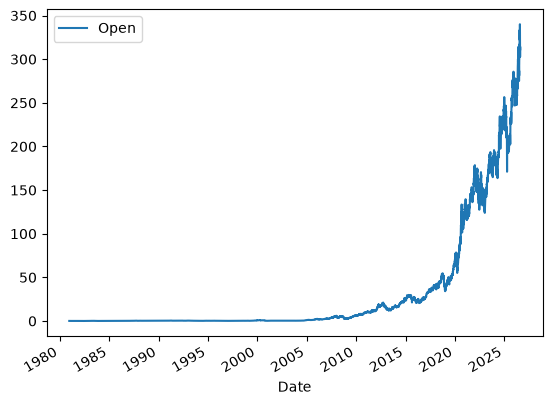

In [17]:
apple_share_price_data.plot(x="Date", y="Open")

### Dividends

In [18]:
apple.dividends

Date
1987-05-11 09:30:00-04:00    0.000536
1987-08-10 09:30:00-04:00    0.000536
1987-11-17 09:30:00-05:00    0.000714
1988-02-12 09:30:00-05:00    0.000714
1988-05-16 09:30:00-04:00    0.000714
                               ...   
2025-05-12 09:30:00-04:00    0.260000
2025-08-11 09:30:00-04:00    0.260000
2025-11-10 09:30:00-05:00    0.260000
2026-02-09 09:30:00-05:00    0.260000
2026-05-11 09:30:00-04:00    0.270000
Name: Dividends, Length: 91, dtype: float64

<Axes: xlabel='Date'>

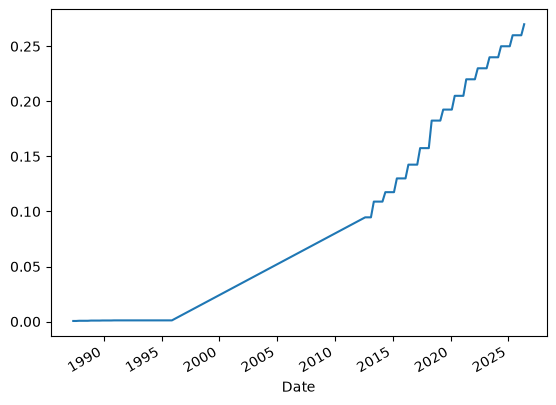

In [19]:
apple.dividends.plot()

## AMD: on my own

Country, sector, and the trading volume on AMD's first day of trading.

In [20]:
amd = yf.Ticker('AMD')

In [21]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/data/amd.json

In [22]:
import json
with open('amd.json') as json_file:
    amd_info = json.load(json_file)
amd_info

{'zip': '95054',
 'sector': 'Technology',
 'fullTimeEmployees': 15500,
 'longBusinessSummary': 'Advanced Micro Devices, Inc. operates as a semiconductor company worldwide. The company operates in two segments, Computing and Graphics; and Enterprise, Embedded and Semi-Custom. Its products include x86 microprocessors as an accelerated processing unit, chipsets, discrete and integrated graphics processing units (GPUs), data center and professional GPUs, and development services; and server and embedded processors, and semi-custom System-on-Chip (SoC) products, development services, and technology for game consoles. The company provides processors for desktop and notebook personal computers under the AMD Ryzen, AMD Ryzen PRO, Ryzen Threadripper, Ryzen Threadripper PRO, AMD Athlon, AMD Athlon PRO, AMD FX, AMD A-Series, and AMD PRO A-Series processors brands; discrete GPUs for desktop and notebook PCs under the AMD Radeon graphics, AMD Embedded Radeon graphics brands; and professional graphi

In [24]:
amd_info['country']

'United States'

In [25]:
amd_info['sector']

'Technology'

In [66]:
amd_history = amd.history(period='max')

amd_history[["Volume"]].iloc[[0]]

,Volume
Date,
1980-03-17 00:00:00-05:00,219600


## What I took away

- `history(period="max")` returns the full price history as a ready-made DataFrame — no scraping needed when an API exists.
- `reset_index()` moves the date out of the index so it can be plotted or merged like any other column.